**Fourier Feature Network using DeepXDE module**

In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
# import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
# from torch.optim.lr_scheduler import ReduceLROnPlateau

Data loading

In [4]:
import os

file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5"

# Check if the file exists
if not os.path.exists(file_path):
    print("File does not exist.")
else:
    print("File exists.")

# Check the file type
with open(file_path, "rb") as f:
    signature = f.read(8)  # HDF5 files start with this signature
    print("File signature:", signature)
    if signature == b"\x89HDF\r\n\x1a\n":
        print("Valid HDF5 file.")
    else:
        print("Not a valid HDF5 file.")


File exists.
File signature: b'\x89HDF\r\n\x1a\n'
Valid HDF5 file.


In [5]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton.h5", 'r')
data_I = np.array(np.array(datastore["I"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))
t = np.linspace(0, 1, 601).reshape(601, 1)

Train-test split

In [6]:
train_label, test_label = train_test_split(range(len(data_I)), test_size=0.25, random_state=42)

data_i_train = data_I[train_label,:]
data_i_test = data_I[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

In [7]:
X_train = data_i_train.astype(np.float32)
y_train_c = data_c_train.astype(np.float32)

In [8]:
X_test = data_i_test.astype(np.float32)
y_test_c = data_c_test.astype(np.float32)

In [9]:
data_c = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_c, X_test=X_test, y_test=y_test_c
)

In [10]:
import tensorflow as tf

def custom_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))  # Example: MSE loss


In [11]:
m = 601
dim_x = 1
net_c = dde.nn.MsFFN(
    [m, 200, 200, 200, m],
    "relu",
    "Glorot normal",
    sigmas = [1, 10]
)

In [12]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [m, 200, 100, 100, m]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 211301


In [13]:
model_c = dde.Model(data_c, net_c)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_c.compile("adam", lr=0.001, metrics=["l2 relative error"])

# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2-1800.ckpt.meta"
# model_c.restore(path)
losshistory_c, train_state_c = model_c.train(iterations=1800, display_every=100)

Compiling model...
Building Multiscale Fourier Feature Network...

'compile' took 0.338313 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.30e+00]    [1.30e+00]    [1.03e+00]    
100       [1.26e-02]    [1.29e-02]    [1.03e-01]    
200       [4.85e-03]    [5.07e-03]    [6.45e-02]    
300       [3.04e-03]    [3.35e-03]    [5.24e-02]    
400       [2.32e-03]    [2.70e-03]    [4.70e-02]    
500       [2.01e-03]    [2.42e-03]    [4.46e-02]    
600       [1.80e-03]    [2.25e-03]    [4.30e-02]    
700       [1.63e-03]    [2.12e-03]    [4.17e-02]    
800       [1.41e-03]    [1.93e-03]    [3.97e-02]    
900       [1.34e-03]    [1.89e-03]    [3.93e-02]    
1000      [1.23e-03]    [1.80e-03]    [3.84e-02]    
1100      [1.29e-03]    [1.89e-03]    [3.94e-02]    
1200      [1.23e-03]    [1.84e-03]    [3.89e-02]    
1300      [1.21e-03]    [1.84e-03]    [3.88e-02]    
1400      [1.04e-03]    [1.68e-03]    [3.71e-02]    
1500      [9.76e-04]    [1.64e-03]    [

In [14]:
y_train_h = data_h_train.astype(np.float32)
y_test_h = data_h_test.astype(np.float32)

In [15]:
data_h = dde.data.dataset.DataSet(
    X_train=X_train, y_train=y_train_h, X_test=X_test, y_test=y_test_h
)

In [16]:
m = 601
dim_x = 1
net_h = dde.nn.MsFFN(
    [m, 200, 100, 100, m],
    "relu",
    "Glorot normal",
    sigmas = [1, 10]
)

In [17]:
model_h = dde.Model(data_h, net_h)
# lr = ReduceLROnPlateau(optimizer_combined, mode='min', factor=0.5, patience=5)
model_h.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory_h, train_state_h = model_h.train(iterations=1800, display_every=100)

Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 0.572244 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [3.47e-01]    [3.45e-01]    [1.16e+00]    
100       [1.15e-02]    [1.16e-02]    [2.12e-01]    
200       [5.01e-03]    [5.16e-03]    [1.42e-01]    
300       [3.73e-03]    [3.89e-03]    [1.23e-01]    
400       [3.10e-03]    [3.28e-03]    [1.13e-01]    
500       [2.80e-03]    [2.98e-03]    [1.08e-01]    
600       [2.67e-03]    [2.85e-03]    [1.05e-01]    
700       [2.48e-03]    [2.66e-03]    [1.02e-01]    
800       [2.27e-03]    [2.45e-03]    [9.75e-02]    
900       [2.32e-03]    [2.50e-03]    [9.85e-02]    
1000      [2.31e-03]    [2.49e-03]    [9.83e-02]    
1100      [3.48e-03]    [3.66e-03]    [1.19e-01]    
1200      [2.14e-03]    [2.32e-03]    [9.50e-02]    
1300      [2.04e-03]    [2.23e-03]    [9.30e-02]    
1400      [2.62e-03]    [2.80e-03]    [1.04e-01]    
1500      [2.28e-03]    [2.47e-03]    [9

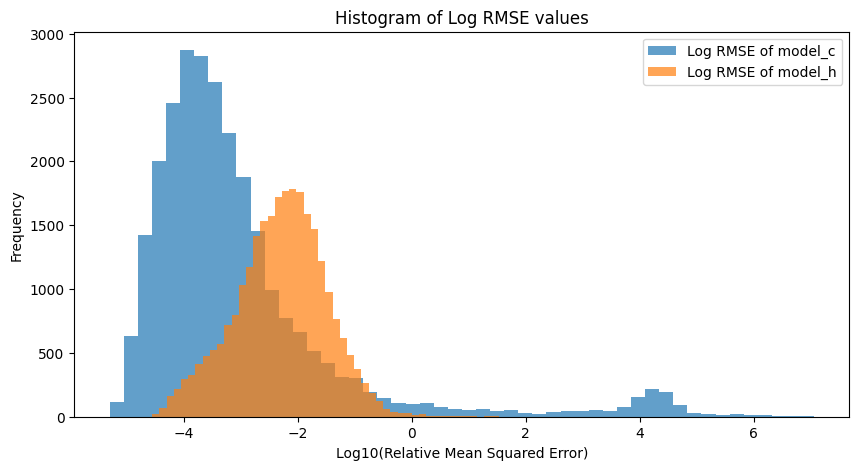

RMSE at c = 2: Mean = 0.007675485306215978, Std = 0.0190542283512743
RMSE at c = 2.5: Mean = 0.024817879051607202, Std = 0.04260960568575271
RMSE at c = 3: Mean = 0.4172135963207134, Std = 0.0


In [33]:
# Use trained model to make predictions
predictions_c = model_c.predict(data_i_test)  # Ensure model_c is defined
predictions_h = model_h.predict(data_i_test)  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c = np.mean((predictions_c - data_c_test) ** 2 / (data_c_test ** 2 + 1e-8), axis=1)  # Averaging across time points
rmse_h = np.mean((predictions_h - data_h_test) ** 2 / (data_h_test ** 2 + 1e-8), axis=1)  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points = [2, 2.5, 3]
errors_at_special_points = {str(point): [] for point in special_points}

for i in range(data_c_test.shape[0]):
    for point in special_points:
        if np.max(data_c_test[i])>=point:
            index = np.argmin(np.abs(data_c_test[i]-point))
            errors_at_special_points[str(point)].append(np.abs((predictions_c[i, index] - data_c_test[i, index])**2))

# Print analysis for special points
for point, errors in errors_at_special_points.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")


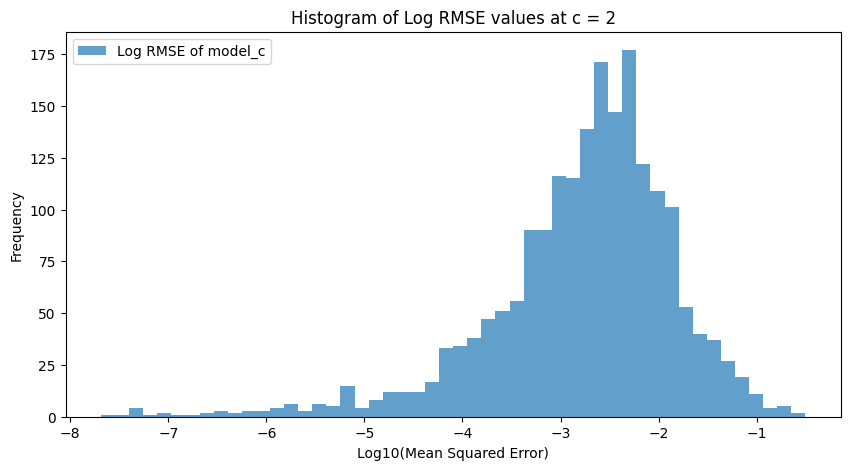

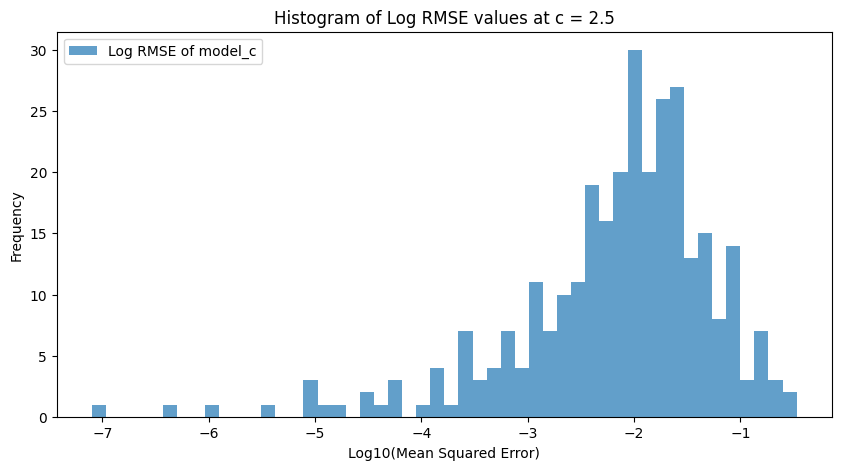

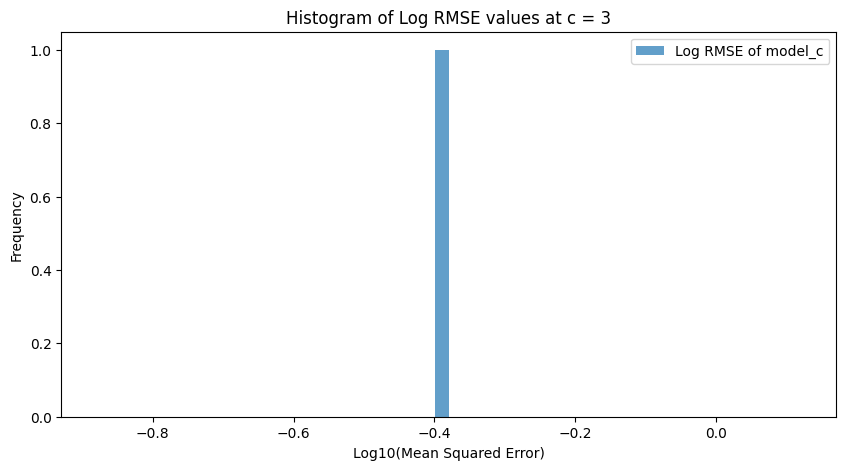

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["2.5"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 2.5')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_special_points["3"]]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at c = 3')
plt.legend()
plt.show()

In [20]:
import numpy as np

def find_sharpest_decline_point(data, mesh=np.linspace(0, 1, 601)):
    """
    Identifies the point where the second derivative is smallest for each function in the input matrix.
    
    Parameters:
        data (numpy.ndarray): A matrix of shape [n, 601] where each row represents a discretized function.
        mesh (numpy.ndarray): The mesh points corresponding to the function values (default: linspace(0, 1, 601)).
    
    Returns:
        numpy.ndarray: An array of shape [n] containing the mesh points where the second derivative is minimum.
    """
    h = mesh[1] - mesh[0]  # Step size
    n = data.shape[0]

    # Compute second derivative using finite difference approximation
    second_derivative = (data[:, :-2] + data[:, 2:] - 2 * data[:, 1:-1]) / (h ** 2)

    # Find the index of the minimum second derivative for each row
    min_indices = np.argmin(second_derivative, axis=1)

    # Map indices to corresponding mesh points
    min_points = mesh[min_indices + 1]  # +1 because second_derivative skips first and last points

    return min_points, min_indices

In [21]:
sharpest_points, sharpest_indices = find_sharpest_decline_point(data_c_test)

errors_at_sharpest_points = []

for i in range(data_c_test.shape[0]):
    errors_at_sharpest_points.append(np.abs((predictions_c[i, sharpest_indices[i]] - data_c_test[i, sharpest_indices[i]])**2))


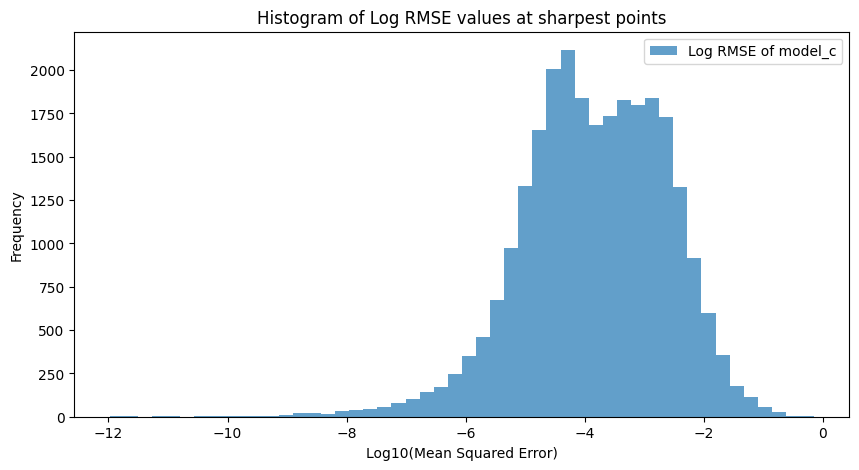

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points')
plt.legend()
plt.show()

1316


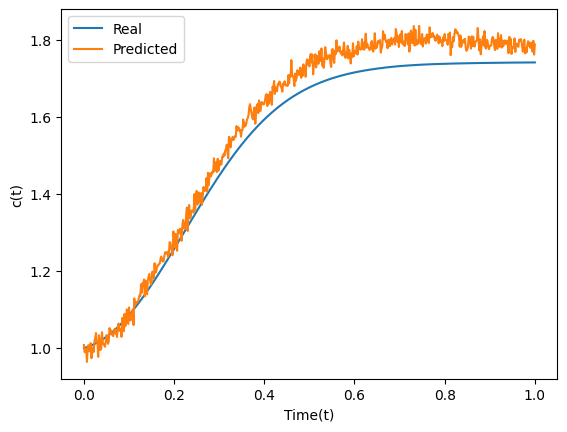

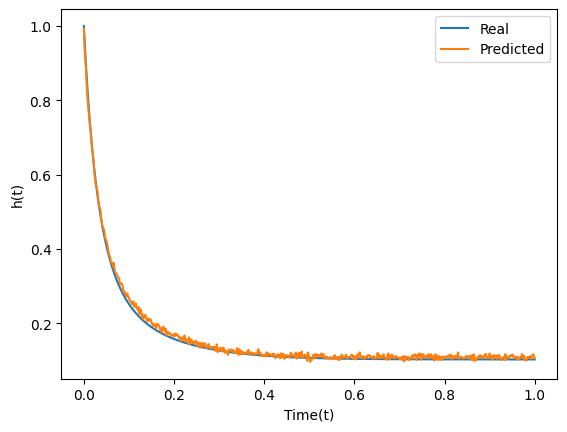

In [23]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

21066


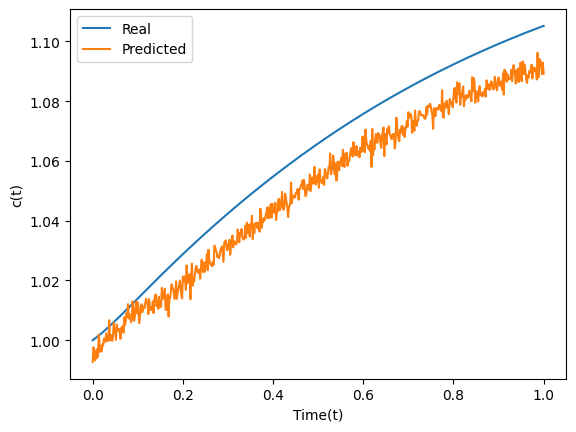

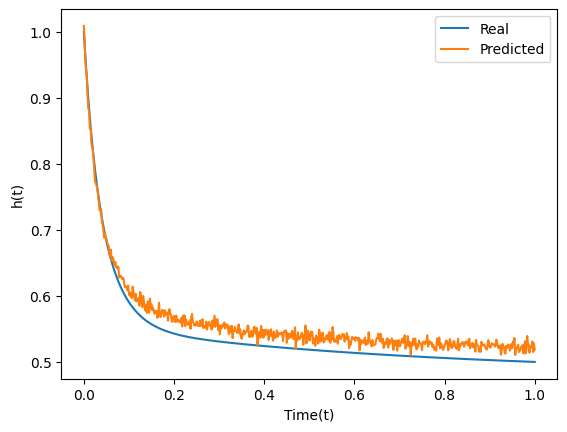

In [24]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

5205


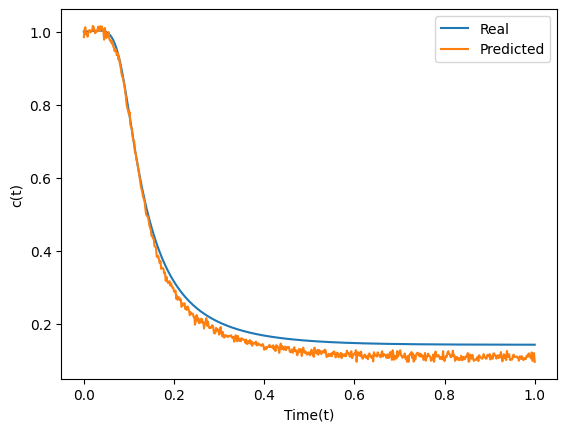

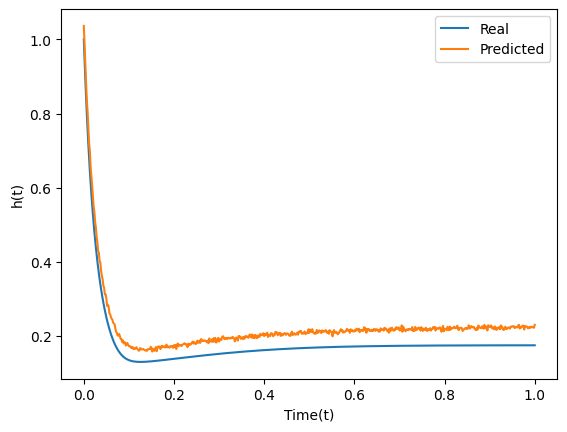

In [25]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

19843


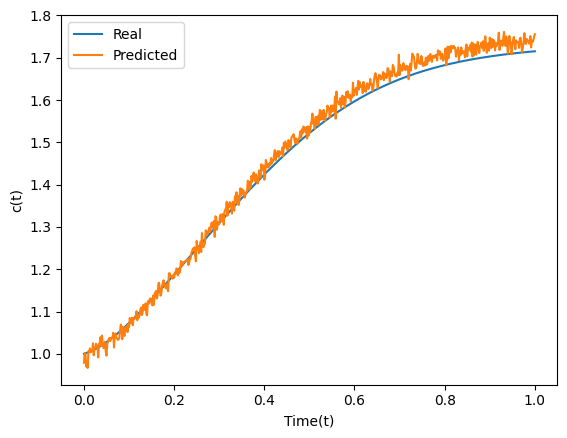

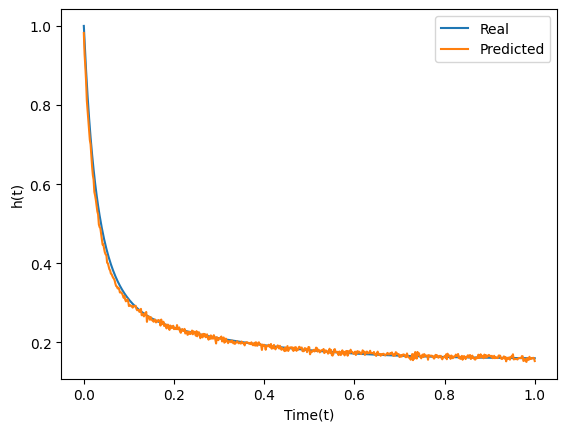

In [26]:
n = np.random.randint(0, len(data_h_test))
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

**Further inspection**

In [27]:
pred_c = model_c.predict(data_i_test)
error_c = np.sum((data_c_test - pred_c)**2, axis=1)/601
max_error_c = np.max(error_c)
print(max_error_c, np.mean(error_c))
max_error_index_c = np.argmax(error_c)
print("Index of max_error:", max_error_index_c)

0.24021794925282702 0.0016368865925821348
Index of max_error: 2228


In [28]:
pred_h = model_h.predict(data_i_test)
error_h = np.sum((data_h_test - pred_h)**2, axis=1)/601
max_error_h = np.max(error_h)
print(max_error_h, np.mean(error_h))
max_error_index_h = np.argmax(error_h)
print("Index of max_error:", max_error_index_h)

0.44246679922575344 0.00239436709531916
Index of max_error: 16304


2228


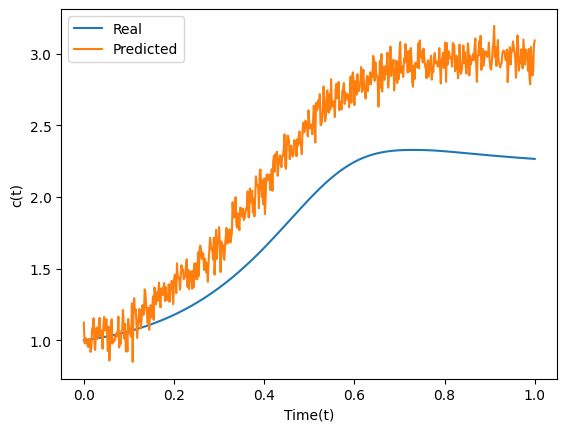

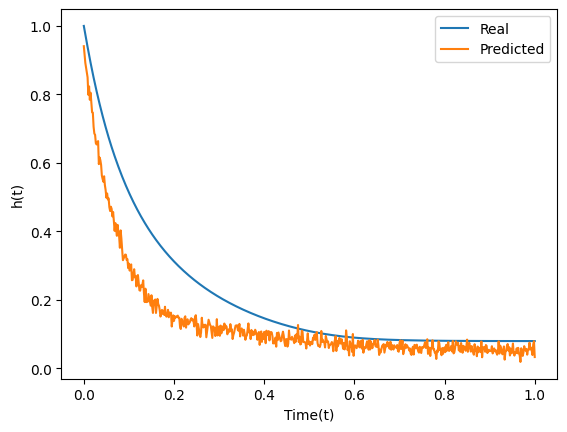

In [29]:
n = max_error_index_c
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

16304


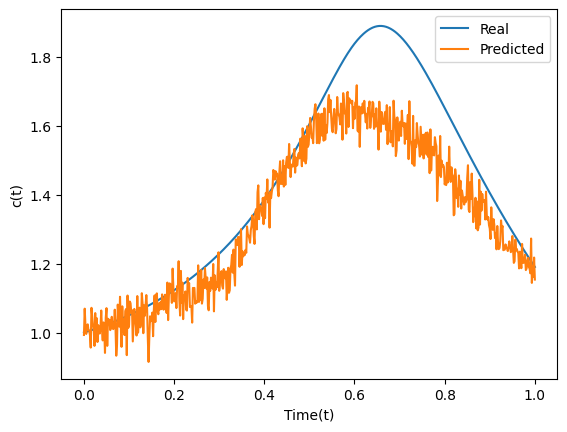

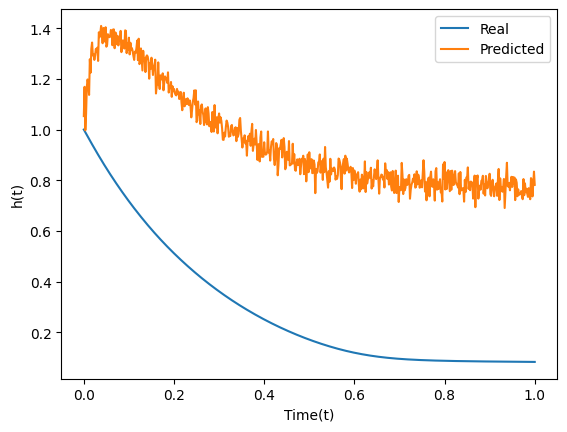

In [30]:
n = max_error_index_h
print(n)
pred_c = model_c.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_c_test[n], label="Real")
plt.plot(t, pred_c.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("c(t)")
plt.legend()
plt.show()

pred_h = model_h.predict(data_i_test[n].reshape(1, -1))
plt.figure()
plt.plot(t, data_h_test[n], label="Real")
plt.plot(t, pred_h.T, label="Predicted")
plt.xlabel("Time(t)")
plt.ylabel("h(t)")
plt.legend()
plt.show()

In [31]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2"
model_c.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2-1800.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_c_ffn2-1800.ckpt'

In [32]:
path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2"
model_h.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2-1800.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/model_h_ffn2-1800.ckpt'

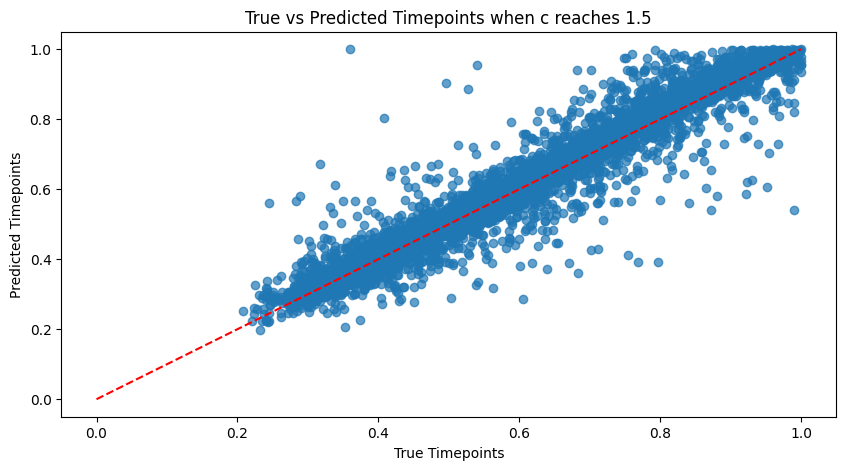

In [38]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 1.5)[0]
    pred_indices = np.where(predictions_c[i] >= 1.5)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 5))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 1.5')
plt.show()

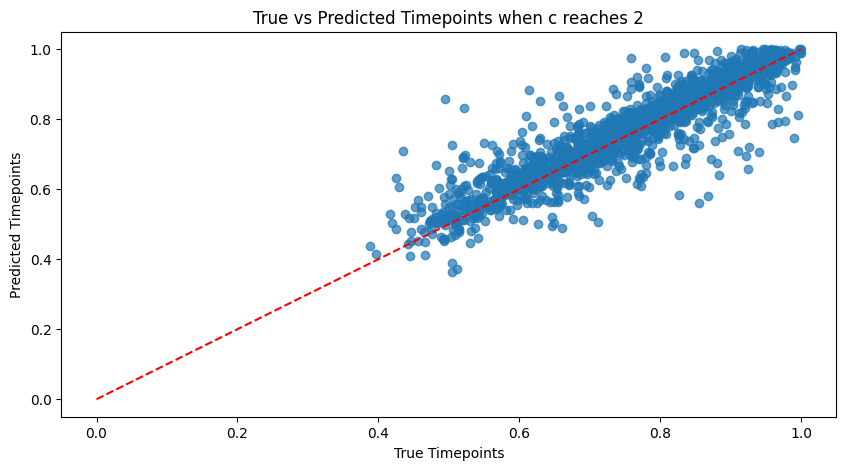

In [35]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 2)[0]
    pred_indices = np.where(predictions_c[i] >= 2)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 5))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 2')
plt.show()

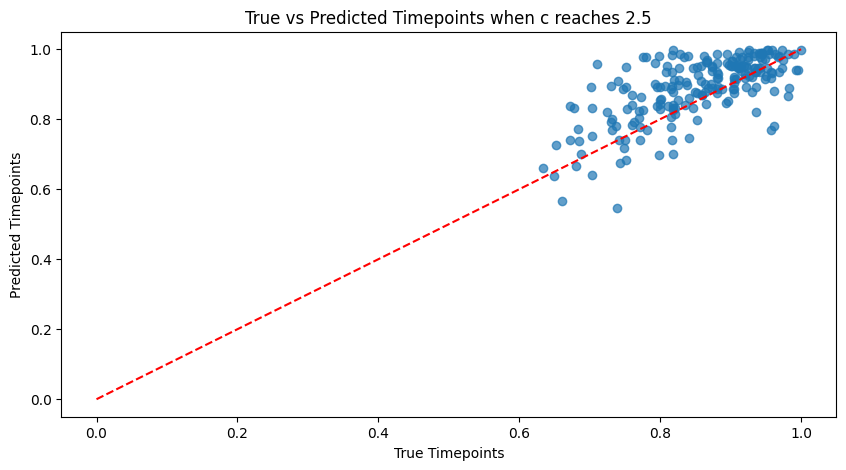

In [37]:
# Identify the timepoints when true value and predicted value of c reach 2
true_timepoints = []
pred_timepoints = []

for i in range(data_c_test.shape[0]):
    true_indices = np.where(data_c_test[i] >= 2.5)[0]
    pred_indices = np.where(predictions_c[i] >= 2.5)[0]
    
    if len(true_indices) > 0 and len(pred_indices) > 0:
        true_timepoints.append(t[true_indices[0]])
        pred_timepoints.append(t[pred_indices[0]])

# Convert lists to numpy arrays for plotting
true_timepoints = np.array(true_timepoints)
pred_timepoints = np.array(pred_timepoints)

# Plot the true timepoints against the predicted timepoints
plt.figure(figsize=(10, 5))
plt.scatter(true_timepoints, pred_timepoints, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--')  # Line y=x for reference
plt.xlabel('True Timepoints')
plt.ylabel('Predicted Timepoints')
plt.title('True vs Predicted Timepoints when c reaches 2.5')
plt.show()

In [39]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/all_data_1d_glob.jld2", 'r')
print(datastore_glob.keys())
data_I_glob = np.array(np.array(datastore_glob["data_I"]))

data_c_glob = np.array(np.array(datastore_glob["data_c"]))
data_h_glob = np.array(np.array(datastore_glob["data_h"]))
para_glob = np.array(np.array(datastore_glob["para3"]))


<KeysViewHDF5 ['data_I', 'data_c', 'data_h', 'para3']>


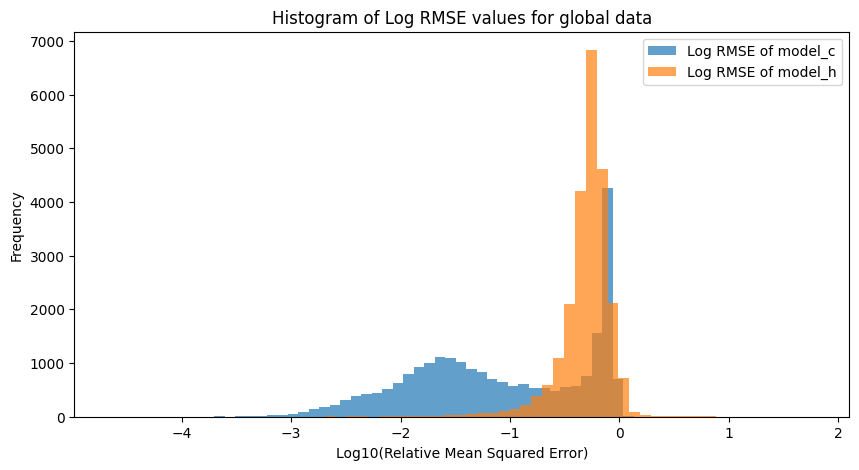

RMSE at c = 2: Mean = 3.222923755645752, Std = 0.840337872505188
RMSE at c = 3: Mean = 8.471840858459473, Std = 0.8940251469612122
RMSE at c = 4: Mean = 15.563078880310059, Std = 1.246517300605774


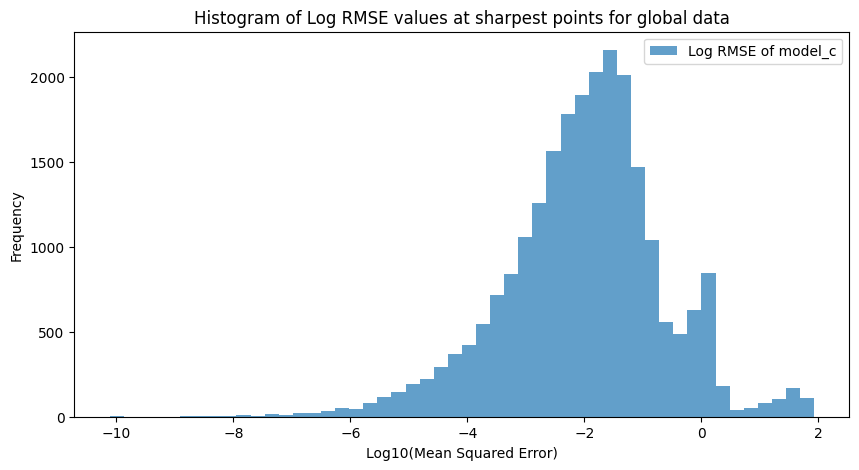

In [40]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
y_test_c_glob = data_c_glob.astype(np.float32)
y_test_h_glob = data_h_glob.astype(np.float32)

# Use trained models to make predictions
predictions_c_glob = model_c.predict(X_test_glob)
predictions_h_glob = model_h.predict(X_test_glob)

# Compute Relative Mean Squared Error (RMSE) for model_c
rmse_c_glob = np.mean((predictions_c_glob - y_test_c_glob) ** 2 / (y_test_c_glob ** 2 + 1e-12), axis=1)
rmse_h_glob = np.mean((predictions_h_glob - y_test_h_glob) ** 2 / (y_test_h_glob ** 2 + 1e-12), axis=1)

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rmse_c_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rmse_h_glob + 1e-8), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data')
plt.legend()
plt.show()

# Inspect performance for c = 2, 3, 4
special_points_glob = [2, 3, 4]
errors_at_special_points_glob = {str(point): [] for point in special_points_glob}

for i in range(y_test_c_glob.shape[0]):
    for point in special_points_glob:
        if np.max(y_test_c_glob[i]) >= point:
            index = np.argmin(np.abs(y_test_c_glob[i] - point))
            errors_at_special_points_glob[str(point)].append(np.abs((predictions_c_glob[i, index] - y_test_c_glob[i, index]) ** 2))

# Print analysis for special points
for point, errors in errors_at_special_points_glob.items():
    if errors:
        print(f"RMSE at c = {point}: Mean = {np.mean(errors)}, Std = {np.std(errors)}")
    else:
        print(f"No data points found for c = {point}")

# Find the sharpest decline points
sharpest_points_glob, sharpest_indices_glob = find_sharpest_decline_point(data_c_glob)

errors_at_sharpest_points_glob = []

for i in range(y_test_c_glob.shape[0]):
    errors_at_sharpest_points_glob.append(np.abs((predictions_c_glob[i, sharpest_indices_glob[i]] - y_test_c_glob[i, sharpest_indices_glob[i]]) ** 2))

# Plot histogram of RMSE values at sharpest points
plt.figure(figsize=(10, 5))
plt.hist(np.log10([error + 1e-12 for error in errors_at_sharpest_points_glob]), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.xlabel('Log10(Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values at sharpest points for global data')
plt.legend()
plt.show()